# Grant Award Categorisation Classifier — eval bench (v3, affiliation-aware)
Iterate the prompt and measure it against your 80-row gold. Inference/pipeline version is separate.

**v2 rules + sharpened ADOPT/ADJACENT + affiliation lookup (prompt-injected).**
1. Recipient matches an OI's host **or a known former-host/founder/conduit org** → DIRECT (bright line).
2. ADOPT = uptake of the OI is the deliverable; ADJACENT = OI is a tool toward another deliverable.
3. UNKNOWN = can't place the relationship (not "doubt the OI is involved").

Human ceiling: raw supercat ~0.73–0.80, κ ≈ 0.59 (leaf κ ≈ 0.47). Land near those = human level.

---

## DESIGN DECISION — affiliation matching is prompt-based (recorded for handover)
**Decision:** the host / former-host / conduit orgs that trigger DIRECT are **injected into the prompt** and the **LLM performs the recipient↔org match**. We did NOT (a) resolve recipients to ROR IDs, nor (b) do a deterministic string match in code.

**Why:** most grant recipients lack ROR IDs, so ROR resolution wasn't worth the build pre-handover; and classifier performance is already at/above human agreement, so the residual matching misses are acceptable.

**Known limitation (documented, not hidden):** the recipient↔org match is done by the model, so it is non-deterministic and some matches will be missed *silently* (e.g. "…and Society" vs "…& Society", university name variants). A missed former-host match reverts that grant to its pre-affiliation classification. If this ever needs to be tightened, the fix is ROR resolution + exact match, or a normalised fuzzy match in code — both turn silent misses into auditable ones.

**For whoever inherits this:** the trigger orgs live in an editable data file (`AFFIL_PATH`), not baked into the prompt. To change what triggers DIRECT, edit that file — do not edit the prompt. Rows deliberately EXCLUDED from triggering (e.g. commercial owners, dev-partners that gold treats as ADOPT) are simply absent from the trigger column; re-adding them will re-introduce over-calls.

---

## 1. Setup

In [ ]:
!pip install anthropic pandas scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.9/956.9 kB 14.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import anthropic, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import time, json, os, ast, re
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from google.colab import userdata
from IPython.display import display
client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))
print("\u2713 setup")

✓ setup


## 2. Configuration

In [21]:
# \u2500\u2500 EDIT \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
GOLD_PATH  = '/content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/award type classifier/award_type_classifer_gold.csv'   # 80 rows: row_no 1-80, adjudicated labels, host, recipient
AFFIL_PATH = '/content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/award type classifier/oi_affiliations_complete.csv'  # reviewed affiliations
CKPT       = '/content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/award type classifier/pred_gold_v3_haiku_3.csv'     # NEW filename (prompt changed)

MODEL = 'claude-haiku-4-5-20251001'
# MODEL = 'claude-sonnet-4-6'

FEWSHOT_ROW_NOS = [1, 7, 9, 14, 28, 29]   # boundary-covering; auto-excluded from eval

# affiliations file column names
AFFIL_OI_COL      = 'oi_name'
AFFIL_TRIGGER_COL = 'triggers_direct_orgs'

API_DELAY = 0.1
CKPT_EVERY = 25
HUMAN_KAPPA_SUPERCAT = 0.59
# \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500

SUPERCATS=['DIRECT','ADJACENT','ADOPT','UNKNOWN']
DIRECT_ACT=['RESEARCH & DEVELOPMENT','OPERATIONS','OTHER']
LEAF=DIRECT_ACT+['ADJACENT','ADOPT','UNKNOWN']
def leaf_to_super(l): return 'DIRECT' if l in DIRECT_ACT else l
print("model:",MODEL,"| few-shot:",FEWSHOT_ROW_NOS)

model: claude-haiku-4-5-20251001 | few-shot: [1, 7, 9, 14, 28, 29]


## 3. Load gold + affiliations lookup

In [10]:
def parse_list(x):
    if pd.isna(x): return []
    s=str(x).strip()
    for L in (json.loads, ast.literal_eval):
        try:
            v=L(s); return [str(i).strip() for i in v] if isinstance(v,list) else [str(v).strip()]
        except: pass
    return [s]

def norm(x):
    if pd.isna(x): return np.nan
    s=re.sub(r'\s+',' ',str(x).strip().upper())
    return {'R&D':'RESEARCH & DEVELOPMENT','RESEARCH AND DEVELOPMENT':'RESEARCH & DEVELOPMENT',
            'OPS':'OPERATIONS','OTHERS':'OTHER','ADOPTION':'ADOPT'}.get(s,s)

def norm_oi(s): return re.sub(r'[^a-z0-9]+','',str(s).lower())

gold=pd.read_csv(GOLD_PATH, quoting=1)
assert 'row_no' in gold.columns
gold['award_supercat']=gold['award_supercat'].map(norm)
gold['award_cat']=gold['award_cat'].map(norm)

# affiliations: build normalized OI -> list of trigger orgs (cleaned)
aff=pd.read_csv(AFFIL_PATH, dtype=str).fillna('')
def clean_orgs(cell):
    orgs=[]
    for o in str(cell).split(';'):
        o=re.sub(r'\([^)]*\)','',o).strip()   # drop parenthetical tags e.g. (UK company)
        if o and o.lower() not in ('none','n/a'): orgs.append(o)
    return orgs
AFF_LOOKUP={ norm_oi(r[AFFIL_OI_COL]): clean_orgs(r[AFFIL_TRIGGER_COL]) for _,r in aff.iterrows() }

def triggers_for(oi_list):
    out=[]
    for oi in oi_list:
        k=norm_oi(oi)
        if k in AFF_LOOKUP: out+=AFF_LOOKUP[k]; continue
        # fallback: substring match against affiliation keys
        for ak,orgs in AFF_LOOKUP.items():
            if ak and (ak in k or k in ak): out+=orgs; break
    # dedupe, preserve order
    seen=set(); res=[]
    for o in out:
        if o.lower() not in seen: seen.add(o.lower()); res.append(o)
    return res

print("Gold rows:",len(gold),"| affiliation OIs:",len(AFF_LOOKUP))
print("example triggers for row 1 OIs:", triggers_for(parse_list(gold.iloc[0]['oi_name']))[:6])

Gold rows: 80 | affiliation OIs: 135
example triggers for row 1 OIs: ['Code for Science & Society']


## 4. System prompt — v2 rules + sharpened ADOPT/ADJACENT + affiliation-aware Rule 1

In [11]:
SYSTEM_PROMPT = """You categorise a research grant by its relationship to the open infrastructure(s) (OI) it involves. OI involvement is already confirmed upstream \u2014 do not question it.

Apply this decision procedure IN ORDER, stopping at the first match:

1) Does the grant's recipient match the OI's HOST organisation, OR any org in "Known DIRECT-trigger orgs" for this grant (these are current/former hosts, founders, and fiscal conduits)? Recipient and org may be worded differently but refer to the same organisation.
   \u2192 DIRECT. Then choose the activity:
      \u2022 RESEARCH & DEVELOPMENT \u2014 R&D incl. software development (may be by an org other than the host).
      \u2022 OPERATIONS \u2014 basic operations, maintenance/updates not counted as new development.
      \u2022 OTHER \u2014 other direct support, or multiple activities with no clear primary one.

2) Otherwise, is the grant's DELIVERABLE the uptake of the OI itself \u2014 a community or institution deploying it, migrating onto it, standing up a new instance of it for others, or driving sector-wide adoption of it? The OI's expanded use IS the goal.
   \u2192 ADOPT.

3) Otherwise, is the OI a TOOL toward a different deliverable (a research output, a digitised collection, a piece of software)? Depositing/uploading into it, ingesting content into it, or building a plug-in/tool FOR it all count here \u2014 the deliverable is the content or tool, not the OI's uptake.
   \u2192 ADJACENT.

4) Otherwise, the OI is genuinely involved but you cannot place the relationship from the information given?
   \u2192 UNKNOWN.

Rules:
\u2022 Rule 1 is a BRIGHT LINE: recipient = host / former-host / conduit \u2192 DIRECT regardless of what the money funds.
\u2022 UNKNOWN means "can't place the relationship" \u2014 NOT "I doubt the OI is involved".
\u2022 Test for 2 vs 3: is getting the OI adopted the deliverable, or a means to another deliverable?
\u2022 Reason briefly, then output ONLY this JSON (no markdown):
{"reasoning":"<one sentence>","supercat":"<DIRECT|ADJACENT|ADOPT|UNKNOWN>","activity":"<RESEARCH & DEVELOPMENT|OPERATIONS|OTHER|null>"}
activity is null unless supercat is DIRECT."""
print(SYSTEM_PROMPT[:280],"...")

You categorise a research grant by its relationship to the open infrastructure(s) (OI) it involves. OI involvement is already confirmed upstream — do not question it.

Apply this decision procedure IN ORDER, stopping at the first match:

1) Does the grant's recipient match the OI ...


## 5. Few-shot from gold (auto-excluded from eval)

In [22]:
def render_input(oi_field, host_field, recipient, title, desc):
    ois=parse_list(oi_field); hosts=parse_list(host_field)
    pairs=[]
    for i,o in enumerate(ois):
        h=hosts[i] if i<len(hosts) and str(hosts[i]) not in ('','nan','None') else 'unknown'
        pairs.append(f"{o} (host: {h})")
    trig=triggers_for(ois)
    lines=[f"OI(s): {'; '.join(pairs) if pairs else 'n/a'}",
           f"Recipient: {recipient if pd.notna(recipient) else 'not available'}"]
    if trig:
        lines.append("Known DIRECT-trigger orgs for these OI(s): " + "; ".join(trig))
    lines += [f"Title: {title}", f"Description: {desc if pd.notna(desc) else ''}"]
    return "\n".join(lines)

fewshot_rows = gold[gold['row_no'].isin(FEWSHOT_ROW_NOS)]
eval_gold    = gold[~gold['row_no'].isin(FEWSHOT_ROW_NOS)].reset_index(drop=True)
print(f"Few-shot: {len(fewshot_rows)} | Eval: {len(eval_gold)}")

FEWSHOT_MSGS=[]
for _,r in fewshot_rows.iterrows():
    inp=render_input(r['oi_name'],r.get('host_organization'),r.get('recipient'),r['grant_title'],r.get('grant_description'))
    sup=r['award_supercat']; leaf=r['award_cat']
    out=json.dumps({"reasoning":"(gold example)","supercat":sup,"activity": leaf if sup=='DIRECT' else None})
    FEWSHOT_MSGS += [{"role":"user","content":inp},{"role":"assistant","content":out}]
print("few-shot messages:",len(FEWSHOT_MSGS))

Few-shot: 6 | Eval: 74
few-shot messages: 12


## 6. Classify function

In [18]:
def classify(oi_field, host_field, recipient, title, desc, max_retries=1):
    msgs = FEWSHOT_MSGS + [{"role":"user","content":render_input(oi_field,host_field,recipient,title,desc)}]
    for att in range(max_retries+1):
        try:
            resp=client.messages.create(model=MODEL,max_tokens=350,system=SYSTEM_PROMPT,messages=msgs)
            raw=resp.content[0].text.strip()
            obj=json.loads(raw.replace("```json","").replace("```","").strip())
            sup=str(obj.get("supercat","")).strip().upper()
            act=obj.get("activity",None)
            act=str(act).strip().upper() if act not in (None,"null","NULL","") else None
            if sup not in SUPERCATS: raise ValueError("bad supercat "+sup)
            if sup=='DIRECT':
                if act not in DIRECT_ACT: raise ValueError("DIRECT needs activity")
                leaf=act
            else:
                act=None; leaf=sup
            return {"leaf":leaf,"supercat":sup,"activity":act,"reasoning":str(obj.get("reasoning","")),"ok":True}
        except Exception as e:
            if att<max_retries: time.sleep(1.0); continue
            return {"leaf":"PARSE_ERROR","supercat":"PARSE_ERROR","activity":None,"reasoning":f"{type(e).__name__}: {e}","ok":False}

_r=eval_gold.iloc[0]
print(classify(_r['oi_name'],_r.get('host_organization'),_r.get('recipient'),_r['grant_title'],_r.get('grant_description')))

{'leaf': 'RESEARCH & DEVELOPMENT', 'supercat': 'DIRECT', 'activity': 'RESEARCH & DEVELOPMENT', 'reasoning': 'Recipient is Modern Language Association, which is listed in Known DIRECT-trigger orgs for Knowledge Commons, making this a DIRECT relationship; the grant funds development of Humanities CORE as part of the Knowledge Commons ecosystem, which constitutes R&D activity.', 'ok': True}


## 7. Run on eval rows (checkpointed on row_no)

In [23]:
done={}
if os.path.exists(CKPT):
    prev=pd.read_csv(CKPT); done={str(r['row_no']):r for _,r in prev.iterrows()}
    print(f"resume: {len(done)} done")
out=[]
for i,r in eval_gold.iterrows():
    rid=str(r['row_no'])
    if rid in done: out.append(done[rid]); continue
    res=classify(r['oi_name'],r.get('host_organization'),r.get('recipient'),r['grant_title'],r.get('grant_description'))
    out.append({'row_no':r['row_no'],'oi_name':r['oi_name'],
                'gold_supercat':r['award_supercat'],'gold_cat':r['award_cat'],
                'pred_supercat':res['supercat'],'pred_cat':res['leaf'],
                'reasoning':res['reasoning'],'ok':res['ok']})
    if (i+1)%CKPT_EVERY==0: pd.DataFrame(out).to_csv(CKPT,index=False); print(f"  {i+1}/{len(eval_gold)}")
    time.sleep(API_DELAY)
pred=pd.DataFrame(out); pred.to_csv(CKPT,index=False)
print("done. parse errors:",(~pred['ok']).sum())

  25/74
  50/74
done. parse errors: 0


## 8. Evaluate vs gold

=== Super-category vs gold ===
              precision    recall  f1-score   support

      DIRECT       0.86      1.00      0.92        36
    ADJACENT       0.96      0.83      0.89        30
       ADOPT       0.33      0.20      0.25         5
     UNKNOWN       0.33      0.33      0.33         3

    accuracy                           0.85        74
   macro avg       0.62      0.59      0.60        74
weighted avg       0.84      0.85      0.84        74

raw accuracy   : 0.851
Cohen's kappa  : 0.742   | human ceiling ≈ 0.59
→ at/above human level


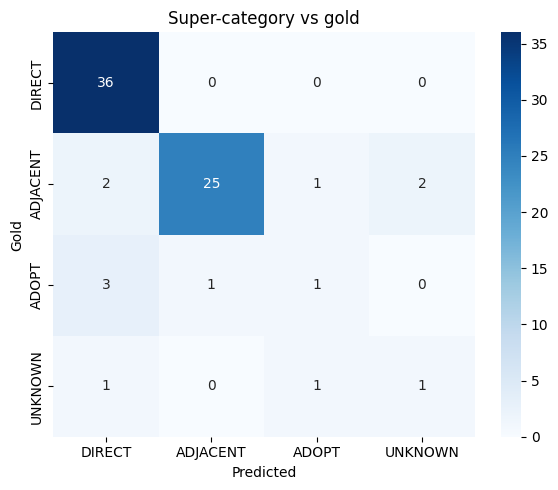

DIRECT/ADJACENT accuracy: 0.924 (n=66)

11 disagreements -> /content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/award type classifier/pred_gold_v3_haiku_3_disagreements.csv
gold_supercat  pred_supercat
ADOPT          DIRECT           3
ADJACENT       UNKNOWN          2
               DIRECT           2
               ADOPT            1
ADOPT          ADJACENT         1
UNKNOWN        ADOPT            1


In [24]:
# reload predictions from checkpoint (cell 7 completed in a previous session)
pred = pd.read_csv(CKPT)

ev=pred[pred['ok']].copy()
print("=== Super-category vs gold ===")
print(classification_report(ev['gold_supercat'],ev['pred_supercat'],labels=SUPERCATS,zero_division=0))
raw=(ev['gold_supercat']==ev['pred_supercat']).mean()
k=cohen_kappa_score(ev['gold_supercat'],ev['pred_supercat'])
print(f"raw accuracy   : {raw:.3f}")
print(f"Cohen's kappa  : {k:.3f}   | human ceiling \u2248 {HUMAN_KAPPA_SUPERCAT}")
print("\u2192","at/above human level" if k>=HUMAN_KAPPA_SUPERCAT-0.03 else "below human ceiling \u2014 read confusions")

cm=confusion_matrix(ev['gold_supercat'],ev['pred_supercat'],labels=SUPERCATS)
plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=SUPERCATS,yticklabels=SUPERCATS)
plt.xlabel('Predicted'); plt.ylabel('Gold'); plt.title('Super-category vs gold'); plt.tight_layout(); plt.show()

da=ev[ev['gold_supercat'].isin(['DIRECT','ADJACENT'])]
if len(da): print("DIRECT/ADJACENT accuracy:",round((da['gold_supercat']==da['pred_supercat']).mean(),3),f"(n={len(da)})")

# disagreement queue
mis=ev[ev['gold_supercat']!=ev['pred_supercat']].merge(
    gold[['row_no','host_organization','recipient','grant_title']],on='row_no',how='left')
mis.to_csv(CKPT.replace('.csv','_disagreements.csv'),index=False)
print(f"\n{len(mis)} disagreements -> {CKPT.replace('.csv','_disagreements.csv')}")
if len(mis): print(mis.groupby(['gold_supercat','pred_supercat']).size().sort_values(ascending=False).head(6).to_string())

## 9. Iteration - results
Haiku and Sonnet were statistically indistinguishable on the 80-award validation set (Cohen's κ ≈ 0.74–0.78 across repeated runs, vs a human inter-annotator ceiling of 0.59), with identical performance on the direct/adjacent distinction that underpins the funding figures. We selected Claude Haiku for production on cost grounds. Both models under-detect the small adoption and unknown classes; those figures are indicative.